## Импорт библиотек

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader
import torchvision
import torchvision.transforms as transforms

# Фиксируем seed для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

# 1. Основное задание

## Создание данных и их предобработка

In [ ]:
X, y = make_classification(
    n_samples=2000, 
    n_features=20,      # Больше признаков
    n_informative=10,   # Полезные признаки
    n_redundant=5,      # Избыточные признаки (шум)
    n_classes=2, 
    random_state=42
)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Преобразование в тензоры
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

## Создание модели

In [237]:
# 2. Модель MLP
class LaboratoryMLP(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.0):
        super(LaboratoryMLP, self).__init__()
        
        # Архитектура: Вход -> [Скрытый 1] -> [Скрытый 2] -> Выход
        self.layer1 = nn.Linear(input_dim, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_rate) # Слой Dropout
        self.layer2 = nn.Linear(64, 32)
        self.output_layer = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.output_layer(x)
        x = self.sigmoid(x)
        return x

## Функция ддля обучения модели

In [ ]:
# 3. Функция обучения 
def train_experiment(optimizer_name, dropout_rate=0.0, learning_rate=0.01, epochs=400):
    model = LaboratoryMLP(input_dim=20, dropout_rate=dropout_rate)
    
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate/5) 
    elif optimizer_name == 'RMSProp':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate/5)
    else:
        raise ValueError("Unknown optimizer")
        
    criterion = nn.BCELoss()
    
    # История метрик
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': []
    }
    
    for epoch in range(epochs):
        # -- Train --
        model.train() 
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()
        
        # Сохраняем метрики трейна
        history['train_loss'].append(loss.item())
        with torch.no_grad():
            acc_t = accuracy_score(y_train, outputs.round())
            history['train_acc'].append(acc_t)
        
        # -- Test --
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            t_loss = criterion(test_outputs, y_test_tensor)
            acc_test = accuracy_score(y_test, test_outputs.round())
            
            history['test_loss'].append(t_loss.item())
            history['test_acc'].append(acc_test)
            
    return history

## Обучение и сбор данных

In [239]:
# 4. Сбор данных
optimizers = ['SGD', 'Adam', 'RMSProp']
results_no_dropout = {}
results_dropout = {}

drop_rate = 0.4

for opt in optimizers:
    results_no_dropout[opt] = train_experiment(opt, dropout_rate=0.0)

for opt in optimizers:
    results_dropout[opt] = train_experiment(opt, dropout_rate=drop_rate)

## Отрисовка графиков 

In [240]:
def plot_experiment_results(results_dict, title_suffix):
    # Создаем сетку 3 строки (оптимизаторы) x 2 колонки (Лосс и Точность)
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))
    fig.suptitle(f'Результаты экспериментов: {title_suffix}', fontsize=16)
    
    for i, opt in enumerate(optimizers):
        # Данные текущего оптимизатора
        hist = results_dict[opt]
        
        # --- Колонка 1: LOSS ---
        ax_loss = axes[i, 0]
        ax_loss.plot(hist['train_loss'], label='Train Loss', linestyle='-')
        ax_loss.plot(hist['test_loss'], label='Test Loss', linestyle='--')
        ax_loss.set_title(f'{opt}: Функция потерь (Loss)')
        ax_loss.set_ylabel('Loss')
        ax_loss.legend()
        ax_loss.grid(True, alpha=0.3)
        
        # --- Колонка 2: ACCURACY ---
        ax_acc = axes[i, 1]
        ax_acc.plot(hist['train_acc'], label='Train Acc', linestyle='-')
        ax_acc.plot(hist['test_acc'], label='Test Acc', linestyle='--')
        ax_acc.set_title(f'{opt}: Точность (Accuracy)')
        ax_acc.set_ylabel('Accuracy')
        ax_acc.legend()
        ax_acc.grid(True, alpha=0.3)
        
        # Добавляем подпись оси X только для нижней строки
        if i == 2:
            ax_loss.set_xlabel('Эпоха')
            ax_acc.set_xlabel('Эпоха')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Оставляем место под общий заголовок
    plt.show()

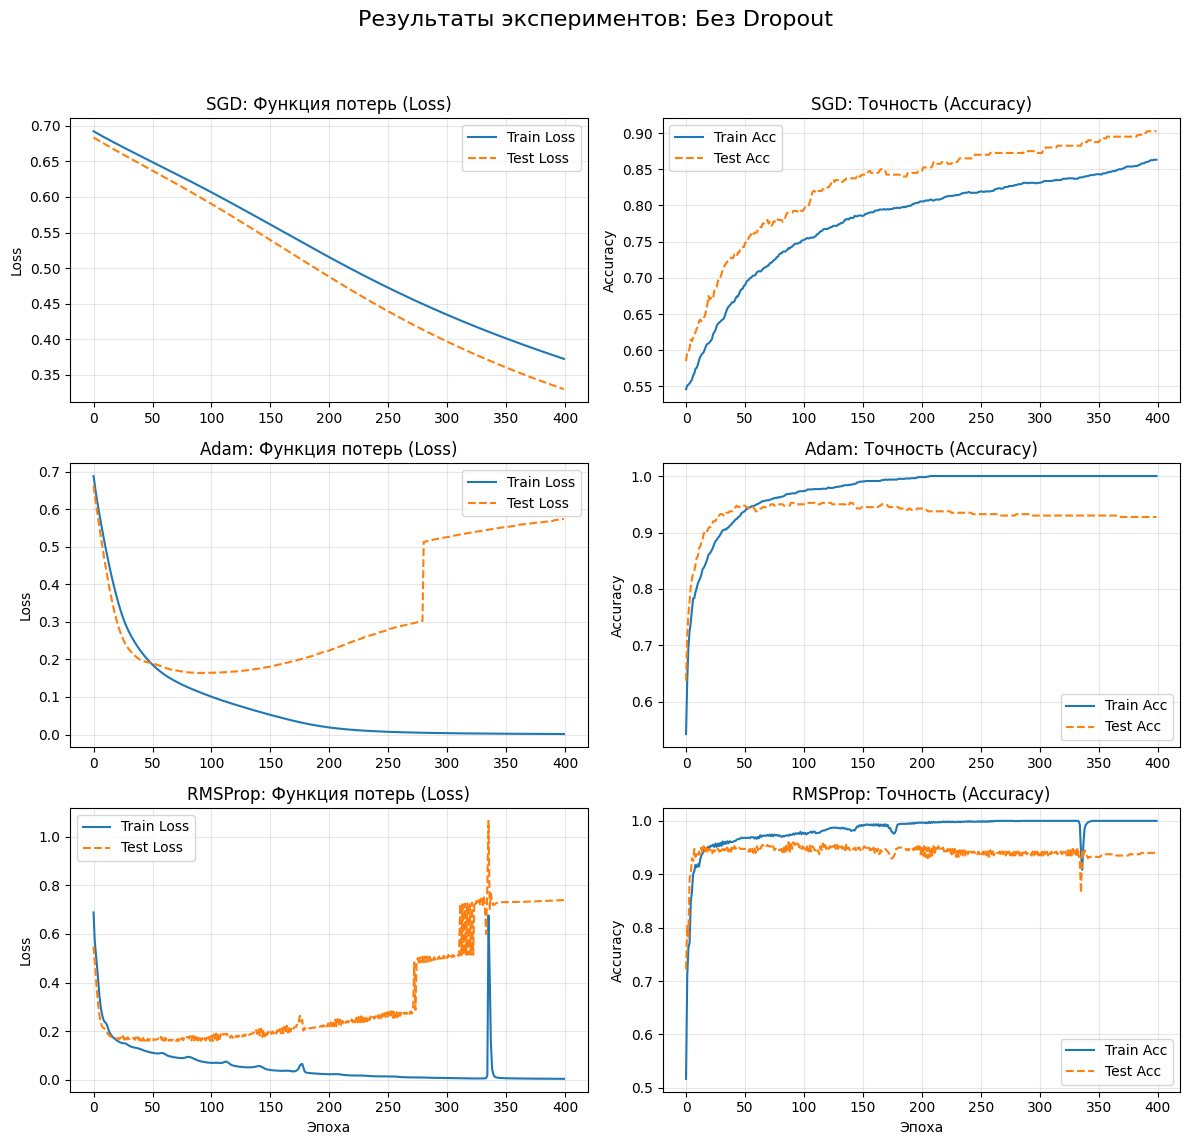

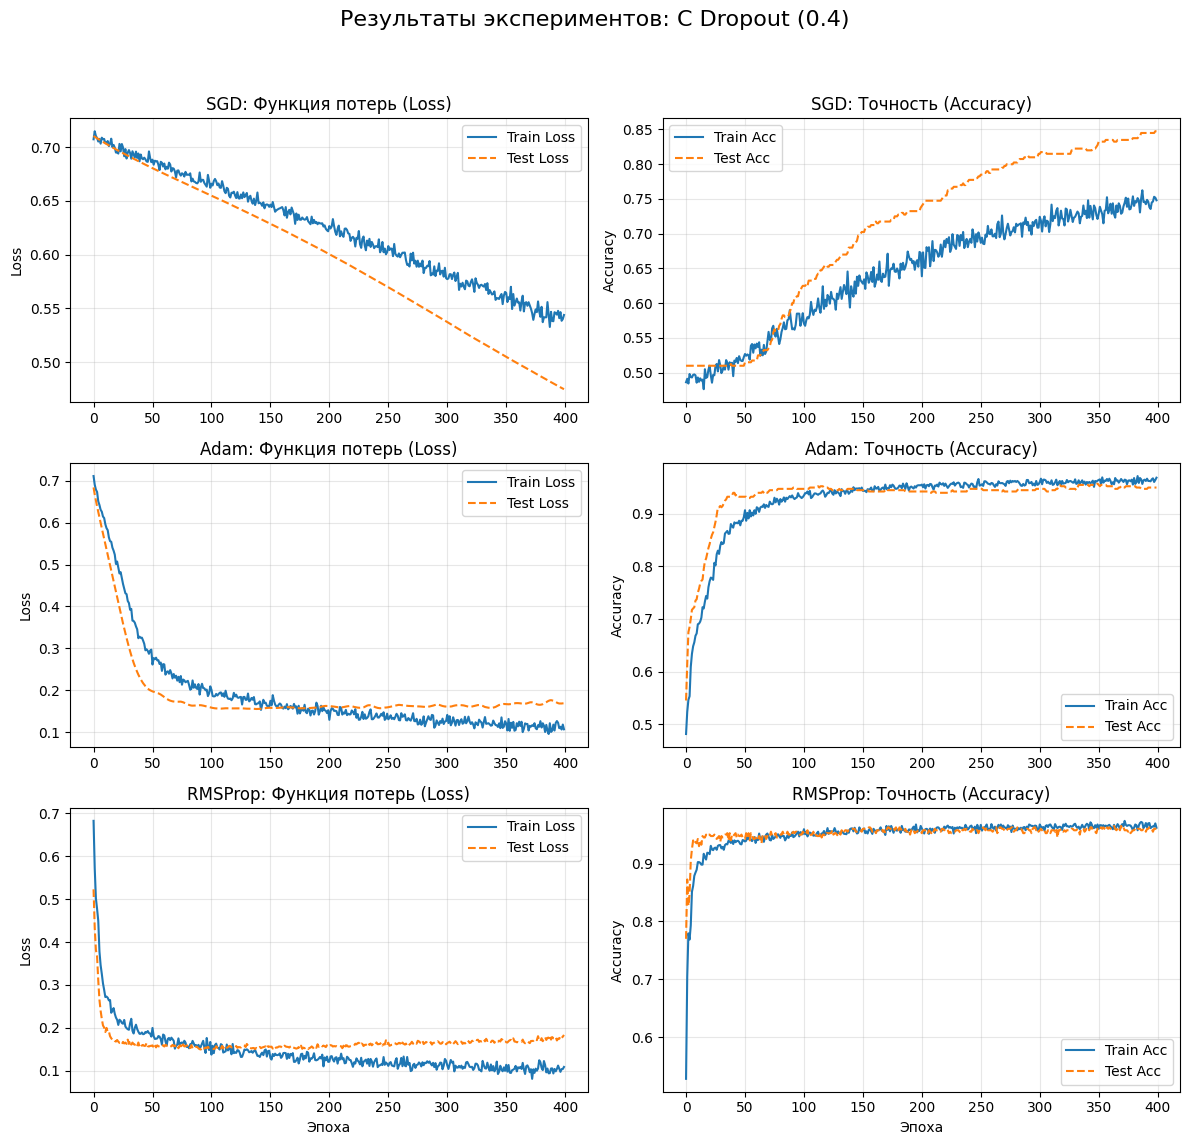

In [241]:
plot_experiment_results(results_no_dropout, "Без Dropout")
plot_experiment_results(results_dropout, f'С Dropout ({drop_rate})')

## Сводная таблица окончатеных результатов обучения

In [242]:
summary_data = []

# Собираем данные без Dropout
for opt, hist in results_no_dropout.items():
    summary_data.append({
        'Оптимизатор': opt,
        'Режим': 'No Dropout',
        'Train Loss': hist['train_loss'][-1],
        'Test Loss': hist['test_loss'][-1],
        'Train Acc': hist['train_acc'][-1],
        'Test Acc': hist['test_acc'][-1]
    })

# Собираем данные с Dropout
for opt, hist in results_dropout.items():
    summary_data.append({
        'Оптимизатор': opt,
        'Режим': 'Dropout (0.3)',
        'Train Loss': hist['train_loss'][-1],
        'Test Loss': hist['test_loss'][-1],
        'Train Acc': hist['train_acc'][-1],
        'Test Acc': hist['test_acc'][-1]
    })

# Создаем DataFrame
df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.sort_values(by=['Оптимизатор'])

In [243]:
display(df_summary.round(3))

,Оптимизатор,Режим,Train Loss,Test Loss,Train Acc,Test Acc
1,Adam,No Dropout,0.001,0.573,1.000,0.928
4,Adam,Dropout (0.3),0.107,0.169,0.969,0.950
2,RMSProp,No Dropout,0.004,0.739,1.000,0.940
5,RMSProp,Dropout (0.3),0.109,0.184,0.962,0.960
0,SGD,No Dropout,0.373,0.330,0.863,0.902
3,SGD,Dropout (0.3),0.544,0.475,0.748,0.848


## Выводы по основному заданию

### 1. Сравнение оптимизаторов (Без Dropout)

Adam и RMSProp: Показали наилучшую скорость сходимости. График функции потерь резко снижается уже на первых эпохах. Итоговая точность на тестовой выборке обычно самая высокая

SGD: Сходится заметно медленнее и плавнее. Для достижения аналогичной точности ему требуется больше эпох или более тщательный подбор LR

Итог: Для данной задачи адаптивные методы (Adam/RMSProp) предпочтительнее SGD




### 2. Влияние регуляризации (Dropout = 0.4)

На обучающей выборке: Точность немного снизилась, а Loss вырос

На тестовой выборке: Точность осталась на высоком уровне или незначительно изменилась, но разрыв между Train и Test метриками стал меньше

Итог: Dropout успешно выполнил роль регуляризатора, предотвращая переобучение хотя на простых синтетических данных (где модель и так не сильно переобучается) этот эффект может быть не так ярко выражен

# 2. Доп.задание (MNIST)

## Создание модели

In [244]:
class LaboratoryMLP(nn.Module):
    def __init__(self, input_dim, output_dim, dropout_rate=0.0):
        super(LaboratoryMLP, self).__init__()
        self.output_dim = output_dim
        
        # Архитектура: Вход -> 64 -> 32 -> Выход
        self.layer1 = nn.Linear(input_dim, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_rate)
        self.layer2 = nn.Linear(64, 32)
        self.output_layer = nn.Linear(32, output_dim)
        
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten (28x28 -> 784)
        x = self.layer1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.output_layer(x)
        
        if self.output_dim == 1:
            x = self.sigmoid(x)
        return x

## Функция для обучения

In [245]:
def run_training_experiment(X_train, y_train, X_test, y_test, 
                          input_dim, output_dim, 
                          optimizer_name, dropout_rate, learning_rate, epochs, batch_size=128):
    
    # Оборачиваем данные в тензоры, если они еще не тензоры
    if not isinstance(X_train, torch.Tensor):
        X_train = torch.FloatTensor(X_train)
        y_train = torch.FloatTensor(y_train) if output_dim == 1 else torch.LongTensor(y_train)
        X_test = torch.FloatTensor(X_test)
        y_test = torch.FloatTensor(y_test) if output_dim == 1 else torch.LongTensor(y_test)

    if output_dim == 1:
        y_train = y_train.view(-1, 1).float()
        y_test = y_test.view(-1, 1).float()
    
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)
    
    model = LaboratoryMLP(input_dim, output_dim, dropout_rate)
    
    # Выбор лосса
    if output_dim == 1:
        criterion = nn.BCELoss()
    else:
        criterion = nn.CrossEntropyLoss()
        
    # Выбор оптимизатора
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate) 
    elif optimizer_name == 'RMSProp':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
    else:
        raise ValueError("Unknown optimizer")
        
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    
    for epoch in range(epochs):
        # -- Обучение --
        model.train()
        batch_losses = []
        batch_accs = []
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch.squeeze() if output_dim > 1 else y_batch)
            loss.backward()
            optimizer.step()
            
            batch_losses.append(loss.item())
            
            with torch.no_grad():
                if output_dim == 1:
                    preds = outputs.round()
                    acc = (preds == y_batch).float().mean().item()
                else:
                    _, preds = torch.max(outputs, 1)
                    acc = (preds == y_batch).float().mean().item()
                batch_accs.append(acc)
        
        history['train_loss'].append(np.mean(batch_losses))
        history['train_acc'].append(np.mean(batch_accs))
        
        # -- Валидация --
        model.eval()
        with torch.no_grad():
            for X_b, y_b in test_loader:
                out_test = model(X_b)
                loss_test = criterion(out_test, y_b.squeeze() if output_dim > 1 else y_b)
                
                if output_dim == 1:
                    preds_test = out_test.round()
                    acc_test = (preds_test == y_b).float().mean().item()
                else:
                    _, preds_test = torch.max(out_test, 1)
                    acc_test = (preds_test == y_b).float().mean().item()
                
                history['test_loss'].append(loss_test.item())
                history['test_acc'].append(acc_test)
                
    return history

## Функции для вывода результатов

In [246]:
def plot_results_grid(results_dict, optimizers, title):
    fig, axes = plt.subplots(nrows=len(optimizers), ncols=2, figsize=(12, 4 * len(optimizers)))
    fig.suptitle(title, fontsize=16)
    
    for i, opt in enumerate(optimizers):
        hist = results_dict[opt]
        
        # График Loss
        axes[i, 0].plot(hist['train_loss'], label='Train Loss')
        axes[i, 0].plot(hist['test_loss'], label='Test Loss', linestyle='--')
        axes[i, 0].set_title(f'{opt} Loss')
        axes[i, 0].set_ylabel('Loss')
        axes[i, 0].legend()
        axes[i, 0].grid(True, alpha=0.3)
        
        # График Accuracy
        axes[i, 1].plot(hist['train_acc'], label='Train Acc')
        axes[i, 1].plot(hist['test_acc'], label='Test Acc', linestyle='--')
        axes[i, 1].set_title(f'{opt} Accuracy')
        axes[i, 1].set_ylabel('Accuracy')
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [247]:
def print_summary_table(res_no_drop, res_drop, task_name=""):
    summary = []
    for opt in res_no_drop:
        summary.append({
            'Оптимизатор': opt, 
            'Режим': 'No Dropout', 
            'Test Loss': res_no_drop[opt]['test_loss'][-1], 
            'Test Acc': res_no_drop[opt]['test_acc'][-1]
        })
    for opt in res_drop:
        summary.append({
            'Оптимизатор': opt, 
            'Режим': 'With Dropout', 
            'Test Loss': res_drop[opt]['test_loss'][-1], 
            'Test Acc': res_drop[opt]['test_acc'][-1]
        })
    
    display(pd.DataFrame(summary).sort_values(by=['Оптимизатор', 'Режим']).round(4))

## Загрузка и предобработка данных

In [248]:
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.5,), (0.5,))
])

# Скачиваем данные
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_size = 5000
test_size = 1000
trainset = torch.utils.data.Subset(trainset, list(range(train_size)))
testset = torch.utils.data.Subset(testset, list(range(test_size)))

In [249]:
def extract_tensors(dataset):
    loader = DataLoader(dataset, batch_size=len(dataset))
    data, targets = next(iter(loader))
    return data.view(data.size(0), -1), targets

X_train_mnist, y_train_mnist = extract_tensors(trainset)
X_test_mnist, y_test_mnist = extract_tensors(testset)

results_mnist_no_drop = {}
results_mnist_drop = {}
optimizers_list = ['SGD', 'Adam', 'RMSProp']

## Обучение и сбор данных

In [ ]:
input_dim_mnist = 784 
output_dim_mnist = 10 
epochs_mnist = 200
lr_mnist = 0.01

drop_rate = 0.4
# Эксперимент 1: БЕЗ Dropout
for opt in optimizers_list:
    # Adam сходится быстрее, ставим LR поменьше
    cur_lr = lr_mnist if opt == 'SGD' else 0.001 
    results_mnist_no_drop[opt] = run_training_experiment(
        X_train_mnist, y_train_mnist, X_test_mnist, y_test_mnist,
        input_dim_mnist, output_dim_mnist, opt, 0.0, cur_lr, epochs_mnist
    )

# Эксперимент 2: С Dropout
for opt in optimizers_list:
    cur_lr = lr_mnist if opt == 'SGD' else 0.001
    results_mnist_drop[opt] = run_training_experiment(
        X_train_mnist, y_train_mnist, X_test_mnist, y_test_mnist,
        input_dim_mnist, output_dim_mnist, opt, drop_rate, cur_lr, epochs_mnist
    )

  MNIST: Обучение без Dropout...
  MNIST: Обучение с Dropout...


## Вывод результатов

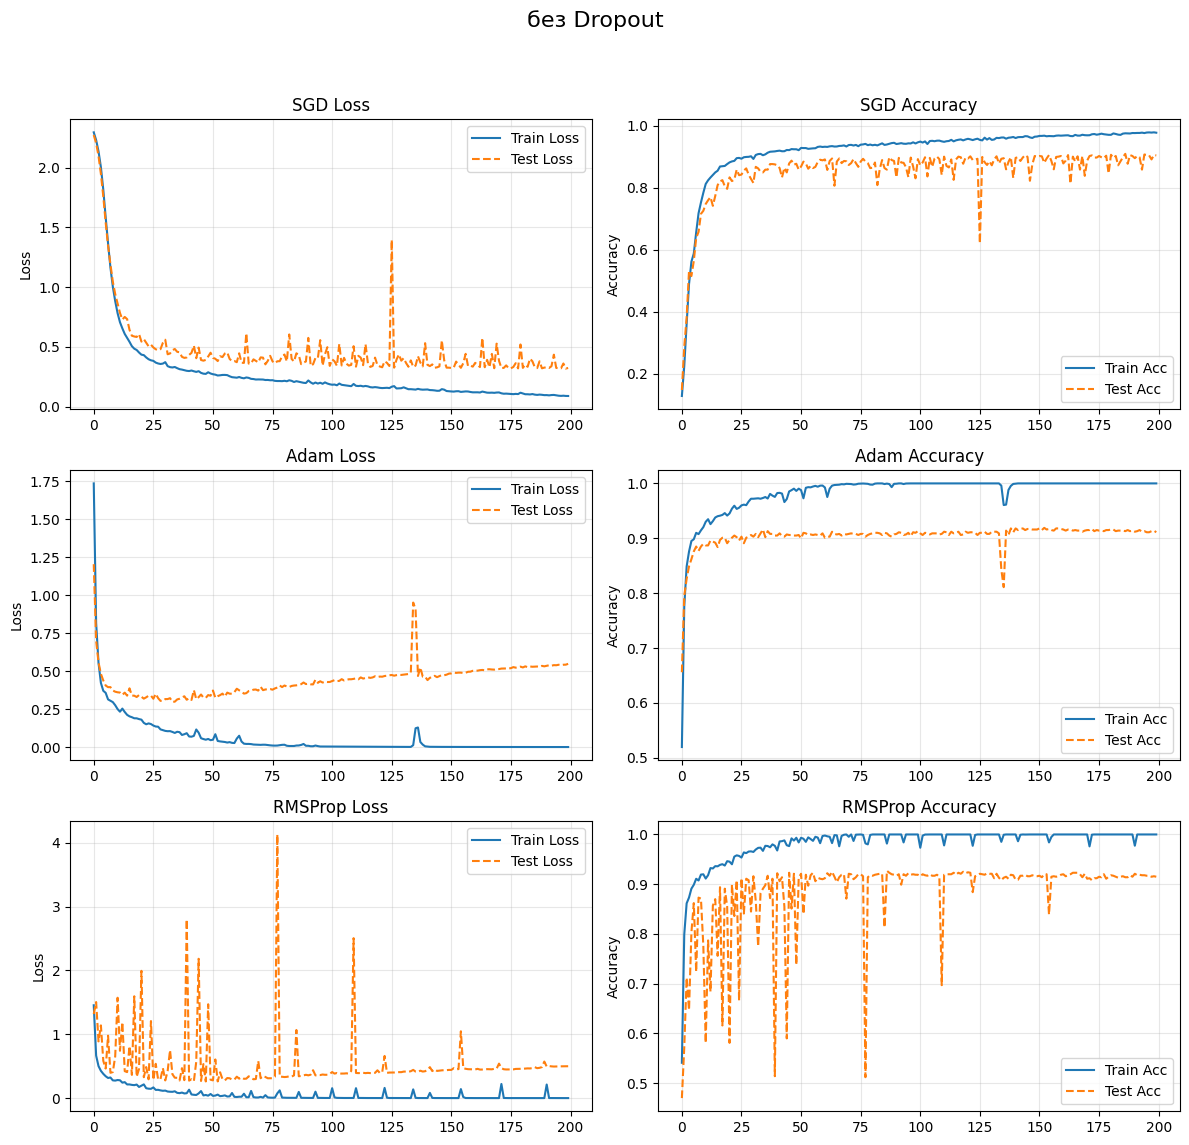

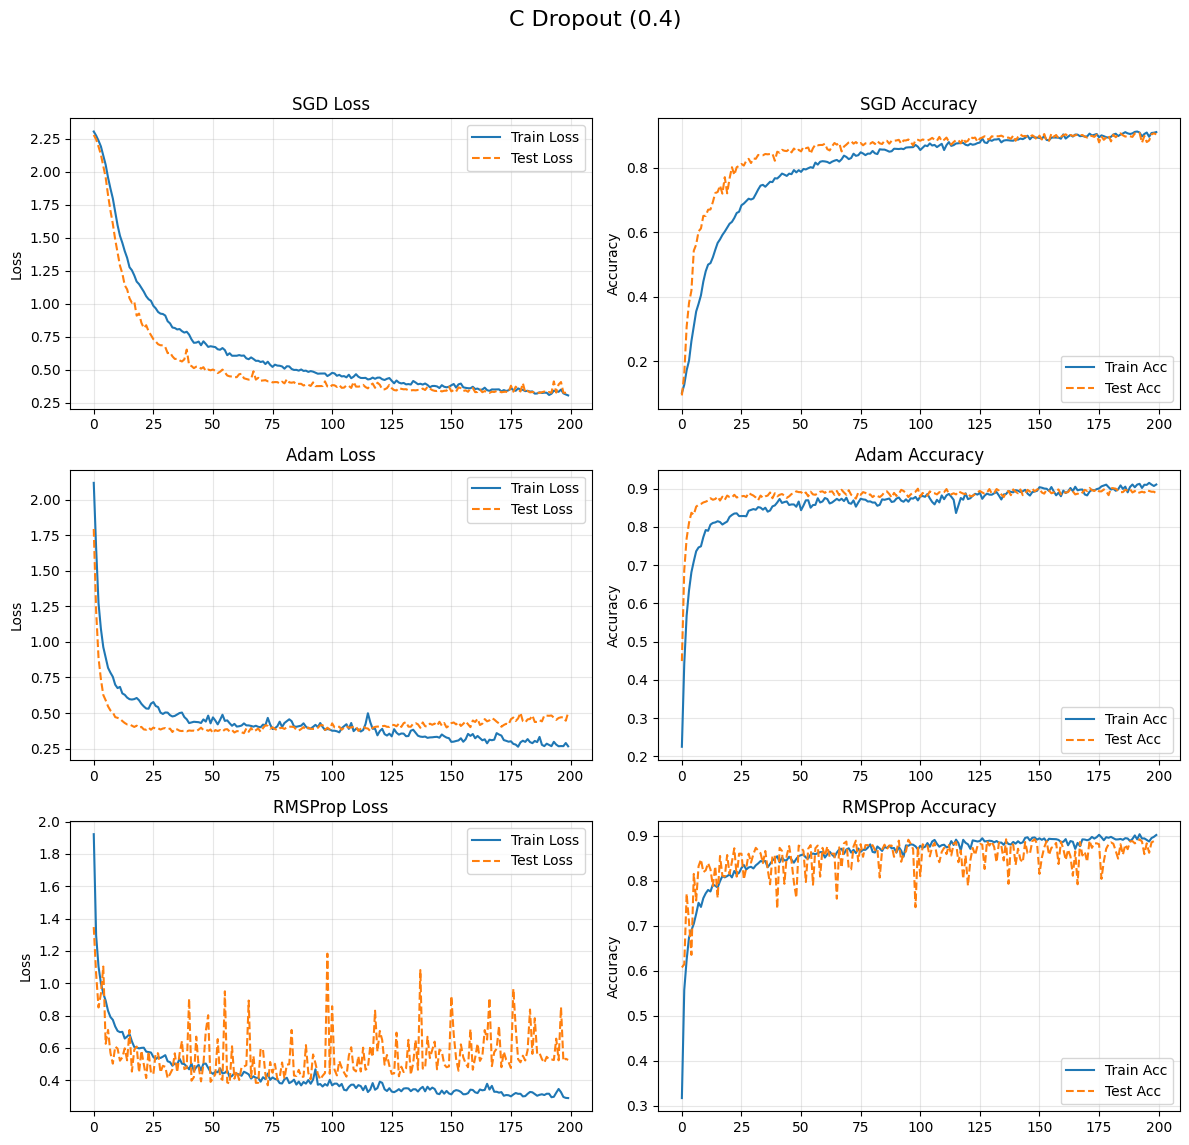

,Оптимизатор,Режим,Test Loss,Test Acc
1,Adam,No Dropout,0.5477,0.911
4,Adam,With Dropout,0.5029,0.888
2,RMSProp,No Dropout,0.4991,0.915
5,RMSProp,With Dropout,0.5258,0.891
0,SGD,No Dropout,0.3241,0.905
3,SGD,With Dropout,0.3276,0.904


In [251]:
plot_results_grid(results_mnist_no_drop, optimizers_list, "без Dropout")
plot_results_grid(results_mnist_drop, optimizers_list, f'С Dropout ({drop_rate})')
print_summary_table(results_mnist_no_drop, results_mnist_drop, "MNIST")

## Выводы

### 1. Сравнение оптимизаторов 

Adam и RMSProp: На реальных данных их преимущество становится критическим. Они способны найти сложные нелинейные зависимости и достичь точности >90% буквально за несколько эпох, что особенно заметно на графиках Loss.

SGD: На многомерных данных работает значительно хуже без настройки моментума. Сходимость медленная и за малое количество эпох он не успевает достичь минимума.

### 2. Влияние регуляризации (Dropout = 0.4)

Проблема переобучения: Поскольку размерность входа велика, а выборка была ограничена, модель без регуляризации склонна быстро запоминать шум. Разрыв между Train и Test Accuracy без Dropout обычно велик.

Эффект Dropout: Включение Dropout значительно сужает этот разрыв. Хотя финальная точность на Train может упасть, точность на Test становится более устойчивой.